# R12 - Predictions with Stochastic Gradient Descent Regression

In [208]:
# Import libraries and set a random state
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import lime, shap
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV
from sklearn.linear_model import SGDRegressor
import warnings
warnings.filterwarnings('ignore')
# random_state = random.randint(1,30)
random_state = 8;  dropna_type = 1;  subset_type = 1;  column_type = 15;  cv_fold = 10

In [209]:
# Read the salary dataset, drop 'id' duplicates
salaries = pd.read_csv('Salaries_v4_202412161100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_3).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_2).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408271150(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408021730(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202402121435.csv')
# salaries = pd.read_csv('Salaries_v3_202401081515.csv')
salaries = salaries.drop_duplicates('id').reset_index()
salaries = salaries.drop(['index','Unnamed: 0'],axis=1)
print("### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###")
print(salaries.isnull().sum()[:16])

### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###
id                      0
found_country           0
title                  12
position                0
employment_type      7157
company              2618
company_score        3815
edu_degrees           554
edu_degrees_major     931
working_year            0
education_score      4598
ms_counts               0
skill_counts            0
main_skills             0
skills                  0
amount_usd              0
dtype: int64


## Select Dropping of Missing Values Strategy

In [210]:
if dropna_type == 1:    print("ROWS WITH MISSING VALUES ARE NOT DROPPED");  
elif dropna_type == 2:  print("DROPPED ALL ROWS WITH MISSING VALUES");  salaries.dropna(inplace=True)
elif dropna_type == 3:  print("DROPPED ROWS WITH MISSING found_country");  salaries.dropna(subset=['found_country'], inplace=True)
elif dropna_type == 4:  print("DROPPED ROWS WITH MISSING title");  salaries.dropna(subset=['title'], inplace=True)
elif dropna_type == 5:  
    print("DROPPED ROWS WITH MISSING employment_type");  salaries.dropna(axis=0, subset=['employment_type'], inplace=True)
elif dropna_type == 6:  print("DROPPED ROWS WITH MISSING company");  salaries.dropna(axis=0, subset=['company'], inplace=True)
elif dropna_type == 7:  
    print("DROPPED ROWS WITH MISSING company_score");  salaries.dropna(axis=0, subset=['company_score'], inplace=True)
elif dropna_type == 8:  print("DROPPED ROWS WITH MISSING edu_degrees");  salaries.dropna(axis=0, subset=['edu_degrees'], inplace=True)
elif dropna_type == 9:  
    print("DROPPED ROWS WITH MISSING edu_degrees_major");  salaries.dropna(axis=0, subset=['edu_degrees_major'], inplace=True)
elif dropna_type == 10:  
    print("DROPPED ROWS WITH MISSING education_score");  salaries.dropna(axis=0, subset=['education_score'], inplace=True)
else:  raise ValueError('Drop N/A type must be between 1 and 10!')

print("This salary dataset contains {} ROWS & {} COLUMNS (DROP N/A TYPE: {})".format(
    salaries.shape[0], salaries.shape[1], dropna_type))

ROWS WITH MISSING VALUES ARE NOT DROPPED
This salary dataset contains 19554 ROWS & 135 COLUMNS (DROP N/A TYPE: 1)


## Dataset Information

In [211]:
# Get the first few rows of the dataset
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,...,0,0,1,0,0,0,0,0,1,0
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,...,0,0,0,0,1,0,0,0,0,1
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,...,0,0,0,0,0,0,0,0,0,1
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,...,0,0,0,0,0,0,0,0,0,0
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,...,0,0,0,1,0,0,1,0,0,0


In [212]:
# Get necessary info about the dataset
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19554 entries, 0 to 19553
Columns: 135 entries, id to skill_communication
dtypes: float64(27), int64(98), object(10)
memory usage: 20.1+ MB


In [213]:
# Get stats about the numerical columns
salaries.describe()

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd,country_coef,country_usa,country_uk,title_slr_coef,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
count,15739.000000,19554.000000,14956.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,...,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000
mean,8.248993,11.449882,8.401484,15.738008,18.777948,163366.552981,0.966054,0.912959,0.087041,0.452360,...,0.258055,0.211824,0.197095,0.177202,0.179094,0.153370,0.205840,0.168252,0.169275,0.193157
std,0.561583,7.213469,1.383108,7.306042,7.814769,81118.159433,0.109942,0.281902,0.281902,0.145708,...,0.437575,0.408611,0.397815,0.381849,0.383441,0.360353,0.404325,0.374099,0.375004,0.394786
min,3.800000,0.000000,1.600000,1.000000,1.000000,21000.000000,0.610000,0.000000,0.000000,0.102000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.100000,6.000000,7.500000,11.000000,15.000000,102000.000000,1.000000,1.000000,0.000000,0.350000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.400000,10.000000,8.600000,16.000000,20.000000,150000.000000,1.000000,1.000000,0.000000,0.484000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.600000,15.000000,9.700000,20.000000,20.000000,210000.000000,1.000000,1.000000,0.000000,0.539000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,57.000000,10.000000,56.000000,82.000000,560000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Select Rows / Columns & Make Train-Test Splits

In [214]:
## GET ANY SUBSET OF THE DATASET
if subset_type == 1:  print("FULL DATASET IS BEING USED")
## Countries
elif subset_type == 2:  print("SUBSET: country_usa");  salaries = salaries[salaries['country_usa'] == 1]
elif subset_type == 3:  print("SUBSET: country_uk");  salaries = salaries[salaries['country_uk'] == 1]
## Titles
elif subset_type == 4:  print("SUBSET: title_has_seniority");  salaries = salaries[salaries['title_has_seniority'] == 1]
elif subset_type == 5:  print("SUBSET: tt_software_eng");  salaries = salaries[salaries['tt_software_eng'] == 1]
elif subset_type == 6:  print("SUBSET: tt_data_analyst");  salaries = salaries[salaries['tt_data_analyst'] == 1]
elif subset_type == 7:  print("SUBSET: tt_data_scientist");  salaries = salaries[salaries['tt_data_scientist'] == 1]
elif subset_type == 8:  print("SUBSET: tt_machine_learning");  salaries = salaries[salaries['tt_machine_learning'] == 1]
elif subset_type == 9:  print("SUBSET: tt_program_manager");  salaries = salaries[salaries['tt_program_manager'] == 1]
## Positions
elif subset_type == 10:  print("SUBSET: position_has_seniority");  salaries = salaries[salaries['position_has_seniority'] == 1]
elif subset_type == 11:  print("SUBSET: pos_software_eng");  salaries = salaries[salaries['pos_software_eng'] == 1]
elif subset_type == 12:  print("SUBSET: pos_data_analyst");  salaries = salaries[salaries['pos_data_analyst'] == 1]
elif subset_type == 13:  print("SUBSET: pos_machine_learning");  salaries = salaries[salaries['pos_machine_learning'] == 1]
elif subset_type == 14:  print("SUBSET: pos_program_manager");  salaries = salaries[salaries['pos_program_manager'] == 1]
elif subset_type == 15:  print("SUBSET: pos_network_engineer");  salaries = salaries[salaries['pos_network_engineer'] == 1]
## Educations
elif subset_type == 16:  print("SUBSET: phd_degree");  salaries = salaries[salaries['phd_degree'] == 1]
elif subset_type == 17:  print("SUBSET: master_degree");  salaries = salaries[salaries['master_degree'] == 1]
elif subset_type == 18:  print("SUBSET: undergrad_degree");  salaries = salaries[salaries['undergrad_degree'] == 1]
## Companies
elif subset_type == 19:  print("SUBSET: comp_google");  salaries = salaries[salaries['comp_google'] == 1]
elif subset_type == 20:  print("SUBSET: comp_amazon");  salaries = salaries[salaries['comp_amazon'] == 1]
elif subset_type == 21:  print("SUBSET: comp_oracle");  salaries = salaries[salaries['comp_oracle'] == 1]
elif subset_type == 22:  print("SUBSET: comp_microsoft");  salaries = salaries[salaries['comp_microsoft'] == 1]
elif subset_type == 23:  print("SUBSET: comp_apple");  salaries = salaries[salaries['comp_apple'] == 1]
elif subset_type == 24:  print("SUBSET: comp_linkedin");  salaries = salaries[salaries['comp_linkedin'] == 1]
## Main Skills
elif subset_type == 25:  print("SUBSET: ms_python");  salaries = salaries[salaries['ms_python'] == 1]
elif subset_type == 26:  print("SUBSET: ms_data_eng");  salaries = salaries[salaries['ms_data_eng'] == 1]
elif subset_type == 27:  print("SUBSET: ms_java");  salaries = salaries[salaries['ms_java'] == 1]
elif subset_type == 28:  print("SUBSET: ms_cpp");  salaries = salaries[salaries['ms_cpp'] == 1]
elif subset_type == 29:  print("SUBSET: ms_mac_learn");  salaries = salaries[salaries['ms_mac_learn'] == 1]
elif subset_type == 30:  print("SUBSET: ms_software_dev");  salaries = salaries[salaries['ms_software_dev'] == 1]
else:  raise ValueError('Salaries subset type must be between 1 and 30!')

# Fill the null values with average for some columns
salaries['company_score'] = salaries['company_score'].fillna(salaries['company_score'].mean())
salaries['education_score'] = salaries['education_score'].fillna(salaries['education_score'].mean())

## GET ANY SUBCOLUMNS OF THE DATASET
if column_type == 1:
    print("BASE NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','amount_usd']]
elif column_type == 2:
    print("ALL NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','country_usa', \
                         'country_uk','title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist', \
                         'tt_machine_learning','tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng', \
                         'tt_bi_analyst','tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer', \
                         'position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng',
                         'employment_full_time','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','comp_amazon','comp_google','comp_oracle','comp_microsoft', \
                         'comp_meta','comp_apple','comp_cisco','comp_aws','comp_ibm','comp_linkedin','comp_capitalone', \
                         'comp_jpmorgan','comp_intel','comp_saic','comp_tata','comp_intuit','comp_uber','comp_qualcomm', \
                         'comp_salesforce','comp_stripe','ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming', \
                         'ms_java','ms_office','ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res', \
                         'ms_html','ms_mac_learn','ms_proj_man','ms_software_dev','ms_cust_serv','ms_research', \
                         'skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 3:
    print("NUMERICAL COLUMNS ONLY WITH >=0.1 CORRELATION")
    salaries = salaries[['company_score','working_year','education_score','country_coef','country_usa','title_has_seniority', \
                         'tt_data_scientist','tt_machine_learning','tt_program_manager','tt_product_manager', \
                         'position_has_seniority','pos_data_scientist','pos_machine_learning','pos_program_manager', \
                         'pos_product_manager','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_computer_eng','ed_computer_science','ed_electric_electronic','ed_philosophy', \
                         'comp_google','comp_apple','comp_linkedin','comp_stripe','ms_python','ms_data_eng','ms_sql', \
                         'ms_cpp','ms_mac_learn','ms_software_dev','skill_sql','skill_python','skill_cpp','skill_mac_learn', \
                         'amount_usd']]
elif column_type == 4:
    print("TITLE COLUMNS ONLY")
    salaries = salaries[['title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist','tt_machine_learning', \
                         'tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng','tt_bi_analyst', \
                         'tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer','amount_usd']]
elif column_type == 5:
    print("POSITION COLUMNS ONLY")
    salaries = salaries[['position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng','amount_usd']]
elif column_type == 6:
    print("EDUCATION DEGREE COLUMNS ONLY")
    salaries = salaries[['highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree','amount_usd']]
elif column_type == 7:
    print("EDUCATION DEGREE MAJOR COLUMNS ONLY")
    salaries = salaries[['ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','amount_usd']]
elif column_type == 8:
    print("COMPANY COLUMNS ONLY")
    salaries = salaries[['comp_amazon','comp_google','comp_oracle','comp_microsoft','comp_meta','comp_apple','comp_cisco', \
                         'comp_aws','comp_ibm','comp_linkedin','comp_capitalone','comp_jpmorgan','comp_intel','comp_saic', \
                         'comp_tata','comp_intuit','comp_uber','comp_qualcomm','comp_salesforce','comp_stripe','amount_usd']]
elif column_type == 9:
    print("MAIN SKILL COLUMNS ONLY")
    salaries = salaries[['ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming','ms_java','ms_office', \
                         'ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res','ms_html','ms_mac_learn', \
                         'ms_proj_man','ms_software_dev','ms_cust_serv','ms_research','amount_usd']]
elif column_type == 10:
    print("SKILL COLUMNS ONLY")
    salaries = salaries[['skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 11:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 10)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst','amount_usd']]
elif column_type == 12:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 20)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts','amount_usd']]
elif column_type == 13:
    print("TOP 25 POSITIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries [['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'ed_computer_science','pos_machine_learning','tt_product_manager','tt_machine_learning','pos_product_manager', \
                         'amount_usd']]
elif column_type == 14:
    print("TOP 25 NEGATIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries[['country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts', \
                         'ms_counts','ms_market_res','comp_saic','tt_qa_engineer','ms_research','amount_usd']]
elif column_type == 15:
    print("BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef', \
                         'title_slr_coef','title_seniority_slr_coef','position_slr_coef','position_seniority_slr_coef', \
                         'employment_type_coef','employment_type_slr_coef','highest_edu_deg_lvl','edu_deg_slr_coef', \
                         'edu_degree_major_coef_max','company_slr_coef','main_skill_slr_coef_avg','amount_usd']]
else:
    raise ValueError('Salaries column type must be between 1 and 10!')

print("SUBSET TYPE:", subset_type, "  COLUMN TYPE:", column_type, "  DATASET SHAPE:", salaries.shape)

FULL DATASET IS BEING USED
BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER
SUBSET TYPE: 1   COLUMN TYPE: 15   DATASET SHAPE: (19554, 18)


In [215]:
# OPTION 1: Make train and test splits; 90% train and 10% test
random_state_in_use = True
X = salaries.drop('amount_usd',axis=1)
y = salaries['amount_usd']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

TRAIN SIZE: (17598, 17) (17598,)  TEST SIZE: (1956, 17) (1956,)


In [216]:
# OPTION 2: Separate train and test sets with exact boundary
# random_state_in_use = False
# X = salaries_alt.drop('amount_usd',axis=1)
# y = salaries_alt['amount_usd']
# x_train = X[:9000];   y_train = y[:9000]
# x_test = X[9000:];    y_test = y[9000:]
# print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

## Create the Model & Evaluate the Predictions

In [217]:
# STOCHASTIC GRADIENT DESCENT
# Linear model fitted by minimizing a regularized empirical loss with SGD.
# SGD stands for Stochastic Gradient Descent: the gradient of the loss is estimated each sample at a time and the model is
# updated along the way with a decreasing strength schedule (aka learning rate).
# The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using
# either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter
# update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow the learning sparse
# models and achieve online feature selection.
# This implementation works with data represented as dense numpy arrays of floating point values for the features.
sgd = SGDRegressor()
sgd.get_params()
# alpha : float, default = 0.0001
# average : bool or int, default = False
# early_stopping : bool, default = False
# epsilon : float, default = 0.1
# eta0 : float, default = 0.01
# fit_intercept : bool, default = True
# l1_ratio : float, default = 0.15
# learning_rate : {'constant', 'optimal', 'invscaling', 'adaptive'}, deafult = 'invscaling'
# loss : {'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default = 'squared_error'
# max_iter : int, default = 1000
# n_iter_no_change : int, default = 5
# penalty : {'l2', 'l1', 'elasticnet', None}, default = 'l2'
# power_t : float, default = 0.25
# random_state : int, RandomState instance, default = None
# shuffle : bool, default = True
# tol : float or None, default = 1e-3
# validation_fraction : float, default = 0.1
# verbose : int, default = 0
# warm_start : bool, default = False

{'alpha': 0.0001,
 'average': False,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.01,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'invscaling',
 'loss': 'squared_error',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'penalty': 'l2',
 'power_t': 0.25,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [218]:
def adjusted_r2_score(r2_score, n, k):
    return 1 - (1-r2_score)*(n-1)/(n-k-1)

In [219]:
# In every execution, SGD regressor can produce slightly different results, so consecutive results are recorded
sgd_mse, sgd_rmse, sgd_mae, sgd_r2, sgd_adj_r2 = [], [], [], [], []
for i in range(3):
    print("######## RUN {} ########".format(i+1))
    ## Fit the training data into the SGD Regression, then make predictions on the test data
    s_time = time.time()
    sgd.fit(x_train, y_train)
    print("FITTING TIME: {:.4f} seconds".format(time.time()-s_time))
    s_time = time.time()
    y_pred = sgd.predict(x_test)
    print("PREDICTION TIME: {:.4f} seconds.".format(time.time()-s_time))

    ## Append the results of metrics into the corresponding lists
    sgd_mse.append(mean_squared_error(y_test, y_pred))
    sgd_rmse.append(mean_squared_error(y_test, y_pred, squared=False))
    sgd_mae.append(mean_absolute_error(y_test, y_pred))
    sgd_r2.append(round(r2_score(y_test, y_pred), 9))
    sgd_adj_r2.append(round(adjusted_r2_score(r2_score(y_test, y_pred), len(y_test), X.shape[1]), 9))

    ## Show the attributes for each SGD Regression
    print("COEF:", sgd.coef_)  # Weights assigned to the features
    print("INTERCEPT:", sgd.intercept_)  # The intercept term
    print("ITERATIONS:", sgd.n_iter_)  # The actual number of iterations before reaching the stopping criterion
    # Number of weight updates performed during training, same as (n_iter_ * n_samples + 1)
    print("WEIGHT UPDATES:", sgd.t_)  
    print("FEATURES:", sgd.n_features_in_, "\n")  # Number of features seen during fit

######## RUN 1 ########
FITTING TIME: 1.7228 seconds
PREDICTION TIME: 0.0020 seconds.
COEF: [ 3.70840279e+05  5.53664828e+04  2.33063176e+05 -6.03813839e+02
 -1.49605299e+04  1.29921036e+06 -4.89212729e+06  5.55134958e+06
  5.68800736e+06 -3.27411824e+06 -9.59249016e+07  1.07065816e+08
 -4.92668112e+06  7.17360519e+06  6.66666419e+04  4.37857021e+05
  3.10683285e+06]
INTERCEPT: [-24586362.24239847]
ITERATIONS: 1000
WEIGHT UPDATES: 17598001.0
FEATURES: 17 

######## RUN 2 ########
FITTING TIME: 1.6612 seconds
PREDICTION TIME: 0.0021 seconds.
COEF: [-2.40672889e+05  2.22687927e+04 -1.19542612e+04 -5.97628390e+03
 -2.08134736e+04 -1.61777552e+06 -3.10077434e+06  2.13287045e+07
  3.63217511e+06 -1.78110325e+07 -2.79559071e+07  3.11021272e+07
  1.66752105e+07 -2.29242919e+07  1.17794213e+06  8.94279094e+05
 -3.55242640e+06]
INTERCEPT: [6237029.73944839]
ITERATIONS: 1000
WEIGHT UPDATES: 17598001.0
FEATURES: 17 

######## RUN 3 ########
FITTING TIME: 1.8005 seconds
PREDICTION TIME: 0.0010 sec

In [220]:
# Results of metrics (all produced results, plus their averages)
if random_state_in_use:
    print("### RESULTS OF METRICS -> RANDOM STATE {} | DROP NA TYPE {} | SUBSET TYPE {} | COLUMN TYPE {} || SIZE {}/{}/{} ###".format(
        random_state, dropna_type, subset_type, column_type, salaries.shape[0], x_train.shape[0], x_test.shape[0]))
else:   print("### SCORES FOR CUSTOM TRAIN-TEST SETS ###")
mse, rmse, mae, r2, adj_r2 = round(sum(sgd_mse) / len(sgd_mse), 4), \
    round(sum(sgd_rmse) / len(sgd_rmse), 4), \
    round(sum(sgd_mae) / len(sgd_mae), 4), \
    round(sum(sgd_r2) / len(sgd_r2), 6), \
    round(sum(sgd_adj_r2) / len(sgd_adj_r2), 6)
print("MSE:", sgd_mse, '->', mse)
print("RMSE:", sgd_rmse, '->', rmse)
print("MAE:", sgd_mae, '->', mae)
print("R2 SCORE:", sgd_r2, '->', r2)
print("ADJUSTED R2 SCORE:", sgd_adj_r2, '->', adj_r2)

# Cross validation is executed only once
s_time = time.time()
cross_val = cross_validate(sgd, X, y, cv=cv_fold, return_train_score=True)
print("\n### CROSS VALIDATION ({}-FOLD) ###".format(cv_fold))
print("FITTING TIME: {} -> {:.8f}".format(cross_val['fit_time'], cross_val['fit_time'].mean()))
print("SCORING TIME: {} -> {:.8f}".format(cross_val['score_time'], cross_val['score_time'].mean()))
print("TRAIN SCORE:  {} -> {:.8f}".format(cross_val['train_score'], cross_val['train_score'].mean()))
print("TEST SCORE:   {} -> {:.8f}".format(cross_val['test_score'], cross_val['test_score'].mean()))     
print("Cross validation was completed in {:.3f} seconds.".format(time.time()-s_time))

### RESULTS OF METRICS -> RANDOM STATE 8 | DROP NA TYPE 1 | SUBSET TYPE 1 | COLUMN TYPE 15 || SIZE 19554/17598/1956 ###
MSE: [17070008747882.377, 3374967386842.004, 2190382292626.0444] -> 7545119475783.476
RMSE: [4131586.7106817905, 1837108.430888608, 1479994.0177669788] -> 2482896.3864
MAE: [1230029.4618624276, 1204969.3571124186, 1094968.4184894362] -> 1176655.7458
R2 SCORE: [-2725.860331413, -538.136495061, -348.904131428] -> -1204.300319
ADJUSTED R2 SCORE: [-2749.780158881, -542.865762561, -351.973465914] -> -1214.873129

### CROSS VALIDATION (10-FOLD) ###
FITTING TIME: [1.90095949 1.93162298 1.70916152 1.74048924 1.73602986 1.87972784
 1.75566483 1.98034048 1.79302025 1.81794357] -> 1.82449601
SCORING TIME: [0.00199294 0.00099516 0.00199175 0.00203252 0.00217938 0.0020051
 0.00262475 0.00232577 0.00204849 0.00159907] -> 0.00197949
TRAIN SCORE:  [-3304.36871745 -4189.76581768  -527.10313581 -1619.02240406
  -868.47487992 -2265.14005374  -750.62376124  -312.75353095
  -505.26570818 

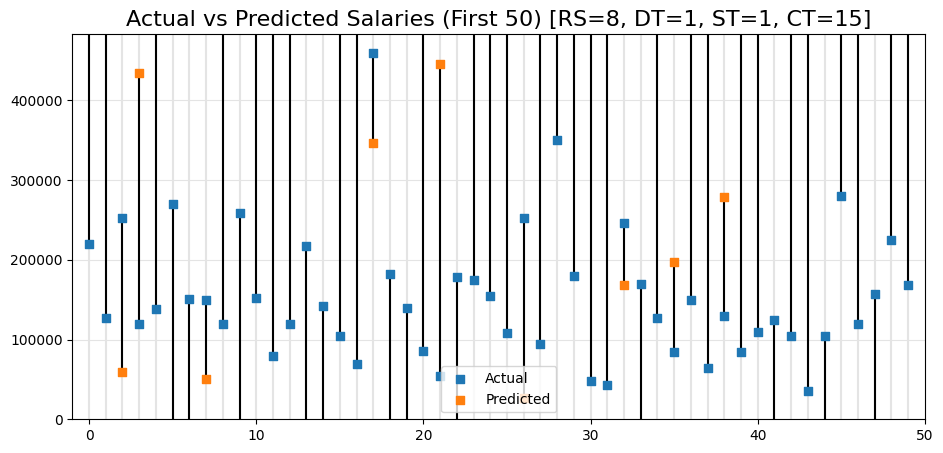

In [221]:
# Compare the predicted salaries against the actual ones in a visualization, for the first 50 salaries of the test set
# Only applicable for the last run of random forest regression
if x_test.shape[0] < 50:  rows = x_test.shape[0]
else:  rows = 50
plt.figure(figsize=(11,5))
plt.axis([-1,rows,0,y_test.iloc[:rows].max()*1.05])
for i in range(rows):
    # print("{:20} | {:8}".format(y_pred[i], y_test.iloc[i]))
    plt.axvline(i, color='#e4e4e4', zorder=2)
plt.scatter(range(rows), y_test.iloc[:rows], marker='s',label='Actual', zorder=4)
plt.scatter(range(rows), y_pred[:rows], marker='s',label='Predicted', zorder=4)
plt.title("Actual vs Predicted Salaries (First {}) [RS={}, DT={}, ST={}, CT={}]".format(
    rows, random_state, dropna_type, subset_type, column_type), fontsize=16)
for i in range(rows):
    plt.axvline(i, ymin=y_test.iloc[i]/(y_test.iloc[:rows].max()*1.05), ymax=y_pred[i]/(y_test.iloc[:rows].max()*1.05), 
                color='black', zorder=3)
plt.legend()
plt.grid(color='#e4e4e4', axis='y', zorder=1)
plt.show()

## Explain the Model with SHAP

In [222]:
shap.initjs()
shap_explainer = shap.Explainer(sgd, x_train)
shap_values = shap_explainer(x_test)
print(shap_values.shape)
print(shap_values)
print("\n EXPECTED VALUE:", shap_explainer.expected_value)

(1956, 17)
.values =
array([[ -33593.49503948,   70011.61035813,   29542.73597961, ...,
         130308.78376541,  311629.66096982,   77410.66969585],
       [ -33593.49503948,  -98691.06520363,    7762.76074801, ...,
         -24245.74108608, -286700.9824799 , 1034212.46636613],
       [-183540.29232715,   48923.77591291, -121793.90482126, ...,
         239784.90553521,  245972.13903375, -726082.28089837],
       ...,
       [-183540.29232715,  133275.11369379,    7762.76074801, ...,
          68057.65570023,  245972.13903375, -527648.24281764],
       [ -33593.49503948,  -35427.56186797,    7762.76074801, ...,
         -85423.57383979, -286700.9824799 ,  287250.54237541],
       [-601706.86190073,  -98691.06520363, -143413.42493567, ...,
        -151967.88315085, -306821.83597644,  399428.40834101]])

.base_values =
array([[842373.02354635],
       [842373.02354635],
       [842373.02354635],
       ...,
       [842373.02354635],
       [842373.02354635],
       [842373.02354635]])



### Global Explainability

### SUMMARY OF EXPLAINABILITY WITH SHAP ###


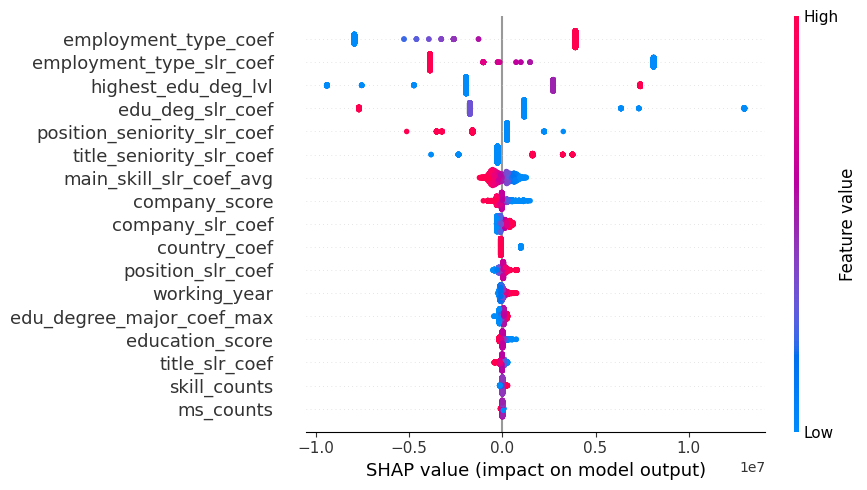

In [223]:
print("### SUMMARY OF EXPLAINABILITY WITH SHAP ###")
# shap.plots.beeswarm(shap_values)
shap.summary_plot(shap_values, x_test, plot_type='dot', plot_size=[9,5])

In [224]:
# print("### VISUALIZATION OF FIRST 100 PREDICTIONS ###")
# shap.plots.force(shap_explainer.expected_value, shap_values[:100])

### MEAN ABSOLUTE VALUES OF SHAP VALUES ###


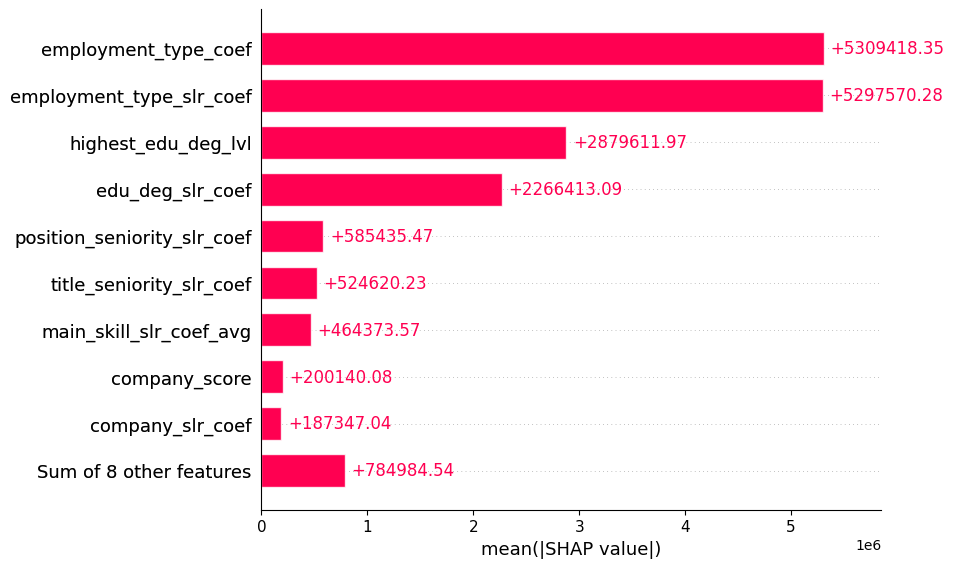

In [225]:
print("### MEAN ABSOLUTE VALUES OF SHAP VALUES ###")
shap.plots.bar(shap_values)

### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###


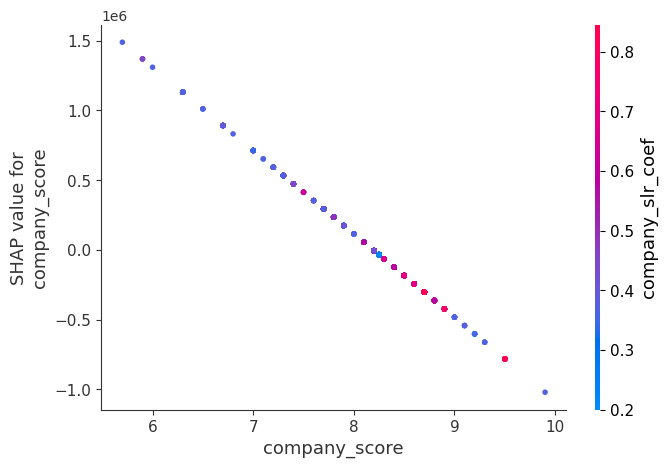

In [226]:
print("### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###")
shap.dependence_plot(x_train.columns[0], shap_values.values, x_test)

### Local Explainability

### EXPLAINING TEST ROW 100 WITH SHAP ###


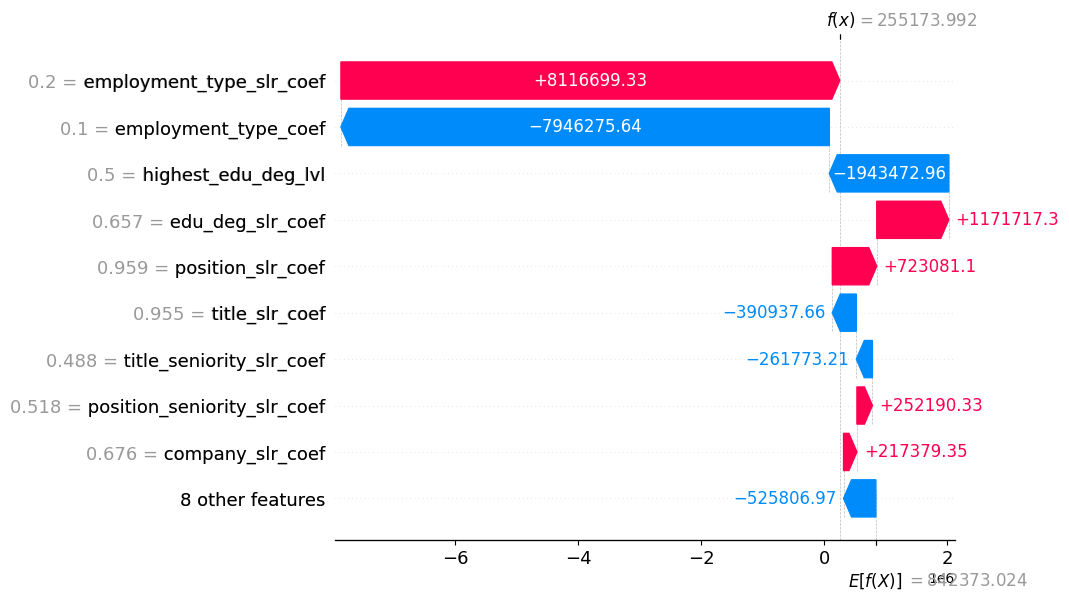

In [227]:
# i = 0
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
shap.plots.waterfall(shap_values[i])

In [228]:
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
shap.plots.force(shap_values[i])

### EXPLAINING TEST ROW 100 WITH SHAP ###


## Explain the Model with LIME

In [229]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(x_train.values, feature_names=salaries.columns, 
                                                        class_names=['amount_usd'], verbose=True, mode='regression')

In [230]:
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH LIME ###".format(i))
exp = lime_explainer.explain_instance(x_test.iloc[i], sgd.predict, num_features=10)
exp.show_in_notebook(show_table=True)
exp.as_list()

### EXPLAINING TEST ROW 1433 WITH LIME ###
Intercept 495343.656418992
Prediction_local [4257547.91226762]
Right: 2845885.6303557865


[('employment_type_slr_coef <= 0.20', 14538300.931010578),
 ('employment_type_coef <= 0.10', -12047487.510817284),
 ('0.50 < highest_edu_deg_lvl <= 0.75', 5054325.117199449),
 ('0.66 < edu_deg_slr_coef <= 0.77', -4210599.840255241),
 ('title_seniority_slr_coef > 0.49', 2311057.727740963),
 ('position_seniority_slr_coef > 0.52', -2257399.372175251),
 ('company_score <= 8.20', 614968.0528247091),
 ('10.00 < working_year <= 15.00', -245099.39474903318),
 ('7.80 < education_score <= 8.40', 237675.772011886),
 ('0.34 < position_slr_coef <= 0.49', -233537.22694214754)]